In [ ]:
from textblob import TextBlob


def analyze_sentiment():
  print("--- Real-Time Sentiment Analyzer ---")
  print("Type any sentence to analyze. Type 'exit' to quit.\n")

  while True:
    user_input = input("Enter Text: ")

    if user_input.lower().strip() == "exit":
      print("Exiting Analyzer.")
      break

    if not user_input.strip():
      continue

    # Process text using TextBlob
    blob = TextBlob(user_input)
    polarity = blob.sentiment.polarity  # Range: -1.0 (Negative) to +1.0 (Positive)
    subjectivity = (
        blob.sentiment.subjectivity
    )  # Range: 0.0 (Factual) to 1.0 (Opinion)

    # Interpret results
    if polarity > 0.1:
      sentiment_label = "POSITIVE 🙂"
    elif polarity < -0.1:
      sentiment_label = "NEGATIVE 🙁"
    else:
      sentiment_label = "NEUTRAL 😐"

    print(f" -> Sentiment: {sentiment_label}")
    print(
        f" -> Score: Polarity={polarity:.2f}, Subjectivity={subjectivity:.2f}\n"
    )


if __name__ == "__main__":
  analyze_sentiment()


--- Real-Time Sentiment Analyzer ---
Type any sentence to analyze. Type 'exit' to quit.



[nltk_data] Downloading package punkt to C:\Users\SHAGUN
[nltk_data]     PRAJAPATI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\SHAGUN
[nltk_data]     PRAJAPATI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Reading books is one of the best habits a person can develop. Books are a valuable source of knowledge, information, and inspiration. Reading regularly helps us improve our vocabulary, grammar, communication skills, and concentration. It also increases our imagination and creativity by allowing us to explore different ideas, characters, cultures, and experiences. Books can teach us important values such as honesty, kindness, courage, patience, and responsibility. Reading biographies of successful people can motivate us to work hard and achieve our goals. Storybooks and novels can provide entertainment while also helping us understand different emotions and perspectives. In today's digital world, people spend a lot of time using mobile phones and social media, so reading books is a healthy and productive way to spend free time. Even reading for a few minutes every day can gradually improve our knowledge and confidence. Books can become our best companions because they are always availab

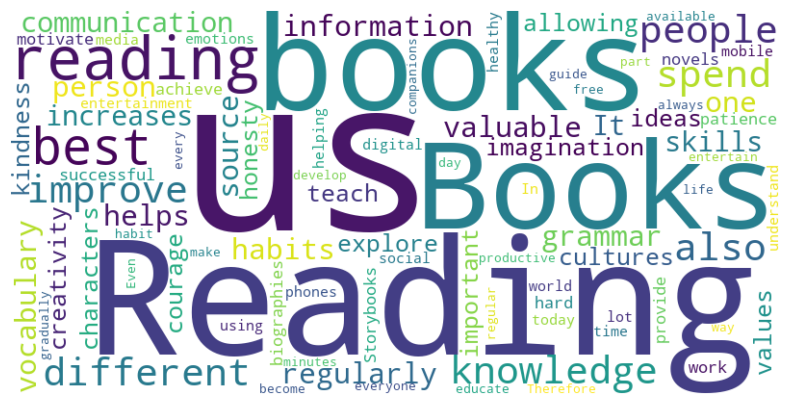

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Ensure necessary NLTK data is downloaded
nltk.download('punkt')
nltk.download('stopwords')
text = text = """Reading books is one of the best habits a person can develop. Books are a valuable source of knowledge, information, and inspiration. Reading regularly helps us improve our vocabulary, grammar, communication skills, and concentration. It also increases our imagination and creativity by allowing us to explore different ideas, characters, cultures, and experiences. Books can teach us important values such as honesty, kindness, courage, patience, and responsibility. Reading biographies of successful people can motivate us to work hard and achieve our goals. Storybooks and novels can provide entertainment while also helping us understand different emotions and perspectives. In today's digital world, people spend a lot of time using mobile phones and social media, so reading books is a healthy and productive way to spend free time. Even reading for a few minutes every day can gradually improve our knowledge and confidence. Books can become our best companions because they are always available to educate, guide, and entertain us. Therefore, everyone should develop the habit of reading books and make it a regular part of their daily life."""
print(text)
# Tokenization of words
words = word_tokenize(text, language="english", preserve_line=True) # Convert to lowercase for uniformity
print(words)
# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
# The general syntax for a list comprehension is: [expression for item in iterable if condition]
print(filtered_words)
# Create a WordCloud
word_freq = Counter(filtered_words)
print(word_freq)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
# Plotting the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.show()

In [11]:
import random
from collections import defaultdict
# 1. Our "Training Data" (The LLM's dataset)
text = "the cat sat on the mat and the dog sat on the rug"
words = text.split()
words
# 2. The Model: Mapping a word to all the words that follow it
model = defaultdict(list)
for i in range(len(words) - 1):
    current_word = words[i]
    next_word = words[i + 1]
    model[current_word].append(next_word)
model
# 3. Text Generation: Start with a word and predict the next ones
current = "the"
output = [current]

for _ in range(5):
    # Look up possible next words and pick one at random
    possible_next_words = model[current]
    next_word = random.choice(possible_next_words)
    output.append(next_word)
    current = next_word

print("Generated text:", " ".join(output))


Generated text: the mat and the cat sat
